## 1. Import Packages

In [1]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import os
import matplotlib.pyplot as plt
import pandas as pd
from scipy.io import loadmat
import torch
import pickle

## 2. Loading duty cycle

In [ ]:
# --- Cell: Load Driving Cycle (Velocity Profile) ---

# Load UDDS drive cycle from .mat file

drive_cycle = loadmat('')  # upload duty cycle .mat file here
time_profile = drive_cycle['t_cyc'].flatten()  # Time in seconds
velocity_ICE = drive_cycle['v_cyc'].flatten()  # Engine speed in RPM
Torque_ICE = drive_cycle['T_cyc'].flatten()    # Torque in Nm
P_dem_raw = Torque_ICE * velocity_ICE * np.pi/30 # Power demand in watts (P = T * ω, where ω = 2π * RPM / 60)

# Check and convert power demand
P_dem= P_dem_raw              # watt

# Total power demand over cycle (for reward normalization)
P_total = np.sum(P_dem) 


assert not np.any(np.isnan(P_dem)), "P_dem contains NaN values"


## 3. Define Parameters

In [ ]:
# --- Cell 2: Define All Parameters (Fill In As Needed) ---
# Environment parameters (to be updated by user)
SOC_min = 0.15 # Minimum state of charge
SOC_max = 0.85 # Maximum state of charge
num_SOC_bins = 100 # Number of bins for state of charge
num_pdem_bins = len(P_dem_raw) # Number of bins for power demand (equal to length of drive cycle)

# Engine parameters
Pe_min =   # Minimum engine power (W)
Pe_max =   # Maximum engine power (W)
num_ICE_bins =  # Number of bins for engine power (adjust as needed)
P_ICE=np.linspace(Pe_min, Pe_max, num_ICE_bins)

# Action space
P_batt_max =  # W (max battery power)
num_action_bins =  # Number of discrete actions for battery power (adjust as needed)
P_batt_bins = np.linspace(-P_batt_max, P_batt_max, num_action_bins)
Q_nom =  # Battery nominal capacity in Coulombs (270 Ah * 3600 s/h)
V_oc = # Open circuit voltage in volts (adjust as needed)

# Q-learning parameters
alpha = 0.001       # Learning rate
gamma = 0.95      # Discount factor
epsilon = 1  # Initial epsilon
epsilon_decay = 0.9999 # Epsilon decay rate per episode
epsilon_min = 0.01 # Minimum epsilon
max_episodes = 50000 # Maximum number of training episodes

# Reward function weights
Kf = 100   # Fuel consumption weight
Ks = 0 # Battery state of charge weight

delta_t = 1.0  # Time step in seconds
action_dim = len(P_batt_bins)

 #--- Hyperparameters ---
batch_size = 64 # Batch size for training
buffer_size = 200000 # Replay buffer size
target_update_freq = 20 # Frequency (in episodes) to update target network



## 4. Get Battery Bounds

In [ ]:
# # --- Cell: Define Function to Get Bounds for Battery Power ---
def get_Pbatt_bounds(SOC, P_dem):

    # Compute bounds based on energy and physical constraints
    lb_soc = ((SOC_max - SOC) * Q_nom * V_oc) / -delta_t # W (lower bound from SOC constraint)
    ub_soc = ((SOC_min - SOC) * Q_nom * V_oc) / -delta_t # W (upper bound from SOC constraint)

    lb = max(lb_soc, -P_batt_max, P_dem - Pe_max) # W (lower bound considering SOC, battery power, and engine power)
    ub = min(ub_soc,  P_batt_max, P_dem)    # W (upper bound considering SOC, battery power, and power demand)

    return lb, ub


## 5. Engine Flowrate Function

In [5]:
def flowrate(P_eng):
        P_eng = np.maximum(P_eng, 0)  # avoid negatives
        
        return (1000*(1.08162718355129e-45 * P_eng**8
          - 1.43068268965849e-39 * P_eng**7
          + 8.20474620926348e-34 * P_eng**6
          - 2.89249358085630e-28 * P_eng**5
          + 7.26048221349760e-23 * P_eng**4
          - 1.20944280881530e-17 * P_eng**3
          + 1.12196161453941e-12 * P_eng**2
          + 6.00334000970419e-09 * P_eng
          + 0))  # Flowrate in g/s

## 6. Define and Initialize Environment (Powertrain)

In [ ]:
# cell 6: Enviroment

class HEVEnvironment:
    def __init__(self, P_dem_raw):
        self.P_dem_raw = P_dem_raw               # in W
        self.SOC_grid = np.linspace(SOC_min, SOC_max, num_SOC_bins)
        self.P_batt_bins = P_batt_bins
        self.SOC = SOC_max
        self.time_step = 0

    def reset(self):
        self.time_step = 0
        self.SOC = SOC_max  
        p_dem = self.P_dem_raw[self.time_step]
        return np.array([self.SOC, p_dem], dtype=np.float32)

    def step(self, action_idx):
        self.time_step += 1
        done = self.time_step >= len(self.P_dem_raw)

        if not done:
            P_dem = self.P_dem_raw[self.time_step]
        else:
            P_dem = self.P_dem_raw[-1]

        if action_idx is None or not np.isfinite(action_idx):
            return np.array([self.SOC , P_dem], dtype=np.float32), -1000, True, {}

        P_batt = np.clip(self.P_batt_bins[action_idx], -P_batt_max, P_batt_max)

        P_eng = np.clip(P_dem - P_batt, Pe_min, Pe_max)
        
        fuel_rate = flowrate(P_eng)
        if not np.isfinite(fuel_rate):
            fuel_rate = 1e3  # ensure fallback value is large to penalize invalid actions

        
        delta_SOC = -delta_t * P_batt / (Q_nom*V_oc) # Change in SOC based on battery power
        SOC_next = self.SOC + delta_SOC # Update SOC based on battery power
        self.SOC = SOC_next # Update SOC based on battery power
        self.SOC = np.clip(self.SOC, SOC_min, SOC_max) # Ensure SOC stays within bounds
    
        fuel_term = -Kf * fuel_rate * delta_t # Fuel consumption penalty
        soc_term = - Ks * abs(self.SOC - 0.55)**2 # Penalize deviation from target SOC of 0.55
        reward = fuel_term + soc_term  # Total reward combining fuel consumption and SOC penalty


        return np.array([self.SOC , P_dem ], dtype=np.float32), reward, done, {
            'P_batt': P_batt,
            'P_eng': P_eng,
            'P_dem': P_dem,
            'fuel_rate': fuel_rate,
            'SOC': self.SOC,
        }

# --- Cell 7: Initialize Environment ---
env = HEVEnvironment( P_dem)
print("Environment initialized.")

Environment initialized.


## 7. Define Agent (DDQN NN)

In [7]:
## Neural Network for Deep Q-learning

class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)


## 8. Replay Buffer

In [ ]:
# --- Replay Buffer with Expert Seeding Support ---
class ReplayBuffer:
    def __init__(self, max_size):
        self.buffer = deque(maxlen=max_size)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def seed(self, transitions):
        """ Seed buffer with expert (rule-based) transitions """
        self.buffer.extend(transitions)

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states, dtype=np.float32),
            np.array(actions),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.uint8)
        )

    def __len__(self):
        return len(self.buffer)



## 9. DDQN Training

In [ ]:
# DDQN loop

# --- Initialize Models and Replay Buffer ---
state_dim = 2  # SOC, speed, P_dem
action_dim = len(P_batt_bins)

q_network = DQN(state_dim, action_dim)
target_network = DQN(state_dim, action_dim)
target_network.load_state_dict(q_network.state_dict())
target_network.eval()

optimizer = torch.optim.Adam(q_network.parameters(), lr=alpha)
loss_fn = nn.MSELoss()
replay_buffer = ReplayBuffer(buffer_size)

epsilon = epsilon
rewards_per_episode = []

for episode in range(max_episodes):
    state = env.reset()
    done = False
    episode_reward = 0

    while not done:
        SOC = state[0]
        P_dem = state[1]

        # Get valid actions
        lb, ub = get_Pbatt_bounds(SOC, P_dem)
        valid_actions = [i for i, pb in enumerate(P_batt_bins) if lb <= pb <= ub]

        # Epsilon-greedy action selection
        if len(valid_actions) == 0:
            action = np.argmin(np.abs(P_batt_bins))  # fallback
        else:
            if np.random.rand() < epsilon:
                action = np.random.choice(valid_actions)
            else:
                with torch.no_grad():
                    q_values = q_network(torch.FloatTensor(state))
                    action = max(valid_actions, key=lambda a: q_values[a].item())

        # Step environment
        next_state, reward, done, _ = env.step(action)
        replay_buffer.push(state, action, reward, next_state, done)

        state = next_state
        episode_reward += reward

    rewards_per_episode.append(episode_reward)

    # Train DQN if buffer is ready
    if len(replay_buffer) >= batch_size:
        states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

        states = torch.FloatTensor(states)
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(next_states)
        dones = torch.BoolTensor(dones).unsqueeze(1)

        q_values = q_network(states).gather(1, actions)

        # Double DQN target
        with torch.no_grad():
            best_actions = q_network(next_states).argmax(1, keepdim=True)
            max_next_q = target_network(next_states).gather(1, best_actions)
            target_q = rewards + gamma * max_next_q * (~dones)

        loss = loss_fn(q_values, target_q)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(q_network.parameters(), 1.0)
        optimizer.step()

    # Decay epsilon
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

    # Target network update
    if episode % target_update_freq == 0:
        target_network.load_state_dict(q_network.state_dict())

    # Logging
    if episode % 10 == 0:
        print(f"Episode {episode}, Reward: {episode_reward:.2f}, Epsilon: {epsilon:.3f}")
        
    if episode % 1000 == 0:
        torch.save({
            'q_network': q_network.state_dict(),
            'target_network': target_network.state_dict(),
            'optimizer': optimizer.state_dict(),
            #'step': step,
            'episode': episode,
            'epsilon': epsilon,
            'rewards_per_episode': rewards_per_episode
        }, f'planter_2_ep{episode}.pth')

    with open('replay_buffer.pkl', 'wb') as f:
        pickle.dump(replay_buffer, f)
        
    try:
        with open('q_values.pkl', 'wb') as f:
            pickle.dump(q_values, f)
    except NameError:
         print("q_value_log not defined. Skipping its save.")



Episode 0, Reward: -477039.94, Epsilon: 0.500
Episode 10, Reward: -543225.80, Epsilon: 0.499
Episode 20, Reward: -374372.28, Epsilon: 0.499
Episode 30, Reward: -393807.40, Epsilon: 0.498
Episode 40, Reward: -489885.88, Epsilon: 0.498


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x000002840870B310>>
Traceback (most recent call last):
  File "C:\Users\habua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipykernel\ipkernel.py", line 796, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
                                                 ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\threading.py", line 1501, in enumerate
    def enumerate():
    
KeyboardInterrupt: 


Episode 50, Reward: -464340.52, Epsilon: 0.497
Episode 60, Reward: -547563.64, Epsilon: 0.497
Episode 70, Reward: -487221.67, Epsilon: 0.496


## 10. Reward Plot

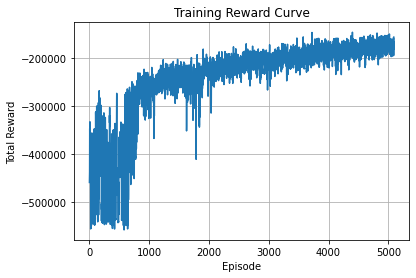

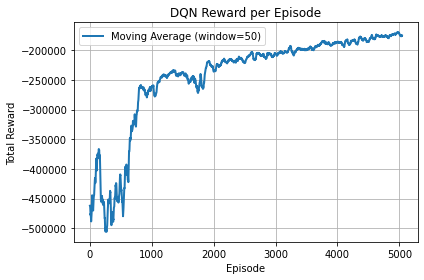

In [24]:
# reward plot
positive_rewards=np.array(rewards_per_episode)
plt.plot(positive_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Reward Curve")
plt.grid(True)
plt.show()

# average reward plot
def moving_average(data, window_size=50):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

smoothed_rewards = moving_average(positive_rewards)


#plt.plot(episode_rewards, label='Episode Reward', alpha=0.4)
plt.plot(smoothed_rewards, label='Moving Average (window=50)', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('DQN Reward per Episode')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 11. Final Policy Evaluation (Forward Simulator)

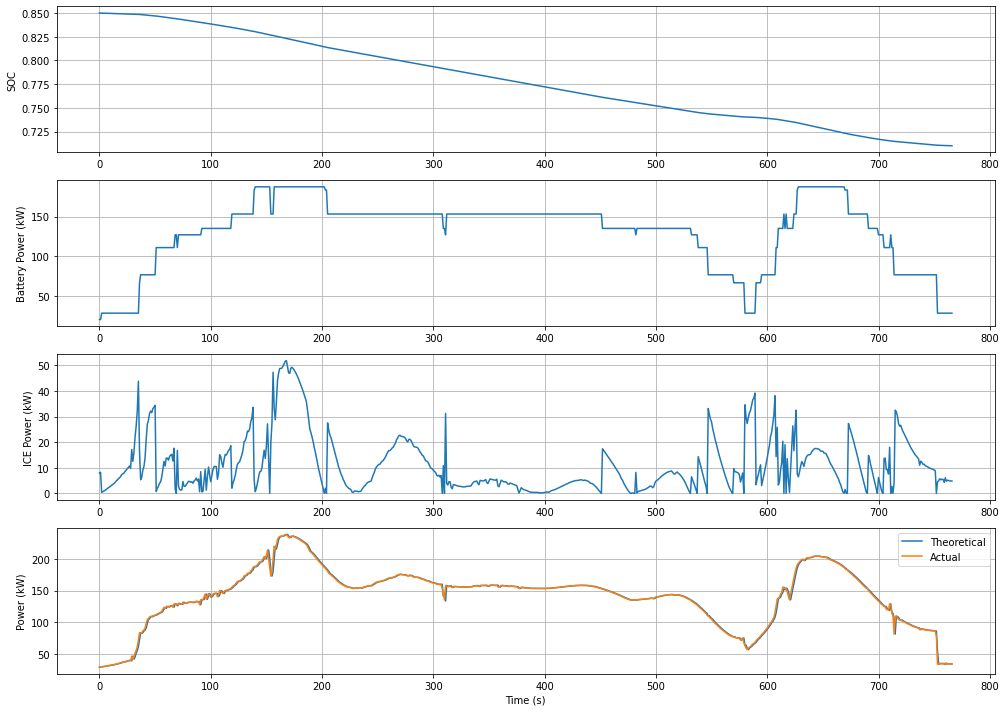

Total fuel consumed: 0.0636 gallons
Max value of soc_list: 0.8499707967401379
Min value of soc_list: 0.7101094321032563
ICE energy: 2.3530 kWh
battery energy: 27.9652 kWh


In [25]:
# --- Forward Simulation Using Optimal Policy (DQN) ---
soc_list = []
p_batt_list = []
p_ice_list = []
fuel_list = []
SOC_target_list = [SOC_max - (np.sum(P_dem_raw[:t]) / P_total) * (SOC_max - 0.65) for t in range(len(P_dem_raw))]
state = env.reset()
SOC_min = 0.

for t in range(len(P_dem_raw)):
    SOC = state[0]
    P_dem = state[1]

    # Get valid battery actions based on bounds and SOC constraints
    lb, ub = get_Pbatt_bounds(SOC, P_dem)
    valid_actions = [i for i, pb in enumerate(P_batt_bins) if lb <= pb <= ub]

    if SOC <= SOC_min:
        valid_actions = [i for i in valid_actions if P_batt_bins[i] < 0]
    elif SOC >= SOC_max:
        valid_actions = [i for i in valid_actions if P_batt_bins[i] > 0]

    if len(valid_actions) == 0:
        action = np.argmin(np.abs(P_batt_bins - P_dem))  # fallback
    else:
        with torch.no_grad():
            q_vals = q_network(torch.FloatTensor(state).unsqueeze(0)).squeeze().numpy()
            action = max(valid_actions, key=lambda a: q_vals[a])

    SOC_target = SOC_target_list[t]
    # Step the environment using the selected action
    next_state, _, done, info = env.step(action)

    # Record metrics
    soc_list.append(info['SOC'])
    p_batt_list.append(info['P_batt'] / 1000)
    p_ice_list.append(info['P_eng'] / 1000)
    fuel_list.append(info['fuel_rate'] * delta_t)

    state = next_state
    if done:
        break


p = [batt + ice for batt, ice in zip(p_batt_list, p_ice_list)]
# --- Plot Results ---
plt.figure(figsize=(14, 10))
plt.subplot(4, 1, 1)
plt.plot(time_profile[:len(soc_list)], soc_list)
#plt.plot(time_profile[:len(SOC_target_list)], SOC_target_list)
plt.ylabel("SOC")
plt.grid(True)
#plt.legend(["SOC", "SOC Target"])

plt.subplot(4, 1, 2)
plt.plot(time_profile[:len(p_batt_list)], p_batt_list)
plt.ylabel("Battery Power (kW)")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(time_profile[:len(p_ice_list)], p_ice_list)
plt.ylabel("ICE Power (kW)")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(time_profile[:len(P_dem_raw)], P_dem_raw/1000)
plt.plot(time_profile[:len(p)], p)
plt.legend(["Theoretical", "Actual"])
plt.ylabel("Power (kW)")
plt.xlabel("Time (s)")
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Final Summary ---
fuel=np.sum(fuel_list)  # Total fuel consumed in g
fuel_density = 842000  # g/m³
volume_m3 = fuel / fuel_density
volume_liters = volume_m3 * 1000
volume_gallons = volume_liters * 0.264172
print(f"Total fuel consumed: {volume_gallons:.4f} gallons")

s=np.max(soc_list)
print("Max value of soc_list:", s)
smin=np.min(soc_list)
print("Min value of soc_list:", smin)

from scipy.integrate import trapz

N = len(p_ice_list)
time_vector = np.arange(1, N) * delta_t  # time in seconds

# Integrate ICE power (kW) over time (s), then convert to kWh
ICE_energy_kWh = trapz(p_ice_list[1:], time_vector) / 3600
print(f'ICE energy: {ICE_energy_kWh:.4f} kWh')

# Integrate ICE power (kW) over time (s), then convert to kWh
battery_energy_kWh = trapz(p_batt_list[1:], time_vector) / 3600
print(f'battery energy: {battery_energy_kWh:.4f} kWh')


## 12. Save Training

In [12]:
import torch
import pickle

# Save core training state
torch.save({
    'q_network': q_network.state_dict(),
    'target_network': target_network.state_dict(),
    'optimizer': optimizer.state_dict(),
    #'step': step,
    'episode': episode,
    'epsilon': epsilon,
    'rewards_per_episode': rewards_per_episode
}, 'cummins_6190_last.pth')

# Save replay buffer
with open('replay_buffer.pkl', 'wb') as f:
    pickle.dump(replay_buffer, f)

# Save Q-value log only if you're using it
try:
    with open('q_values.pkl', 'wb') as f:
        pickle.dump(q_values, f)
except NameError:
    print("q_value_log not defined. Skipping its save.")



q_value_log not defined. Skipping its save.


In [ ]:
rewards = [transition[2] for transition in replay_buffer]

plt.hist(rewards, bins=50)
plt.title("Replay Buffer Reward Distribution")
plt.xlabel("Reward")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [ ]:
torch.save(q_network.state_dict(), 'dqn_policy.pth')
print("Trained DQN policy saved as dqn_policy.pth")

In [ ]:
q_network = DQN(state_dim, action_dim)
q_network.load_state_dict(torch.load('dqn_policy.pth'))
q_network.eval()
print("Trained policy loaded.")
